In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import datasets

from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
import sklearn.model_selection as skm




np.random.seed(327432)


## Przygotowanie ramek danych

Przygotowuję dane do dalszego użytku - wartości ujemne zamieniam na NaN, usuwam wiersze, które zawierają tylko NaN, zamieniam kategorie w y na 1 - Bad i 0 - Good

In [3]:
X = pd.read_csv('X_train.csv')
y = pd.read_csv('y_train.csv')


X[X < 0] = np.nan

X = X.drop(['Unnamed: 0'], axis=1)
y = y.drop(['Unnamed: 0'], axis=1)

#usuwanie wierszy z X i y gdzie wszystkie wiersze są wartościami NuLL
rows_to_remove = X[X.drop(columns=X.columns[0]).isnull().all(axis=1)].index
X= X.drop(rows_to_remove)
y = y.drop(rows_to_remove)


X['X10'] = X['X10'].astype('category')
X['X11'] = X['X11'].astype('category')


In [4]:
y.loc[y['RiskPerformance'] == 'Bad'] = 1
y.loc[y['RiskPerformance'] == 'Good'] = 0

y = y.astype('int')

## Eksploracja Danych

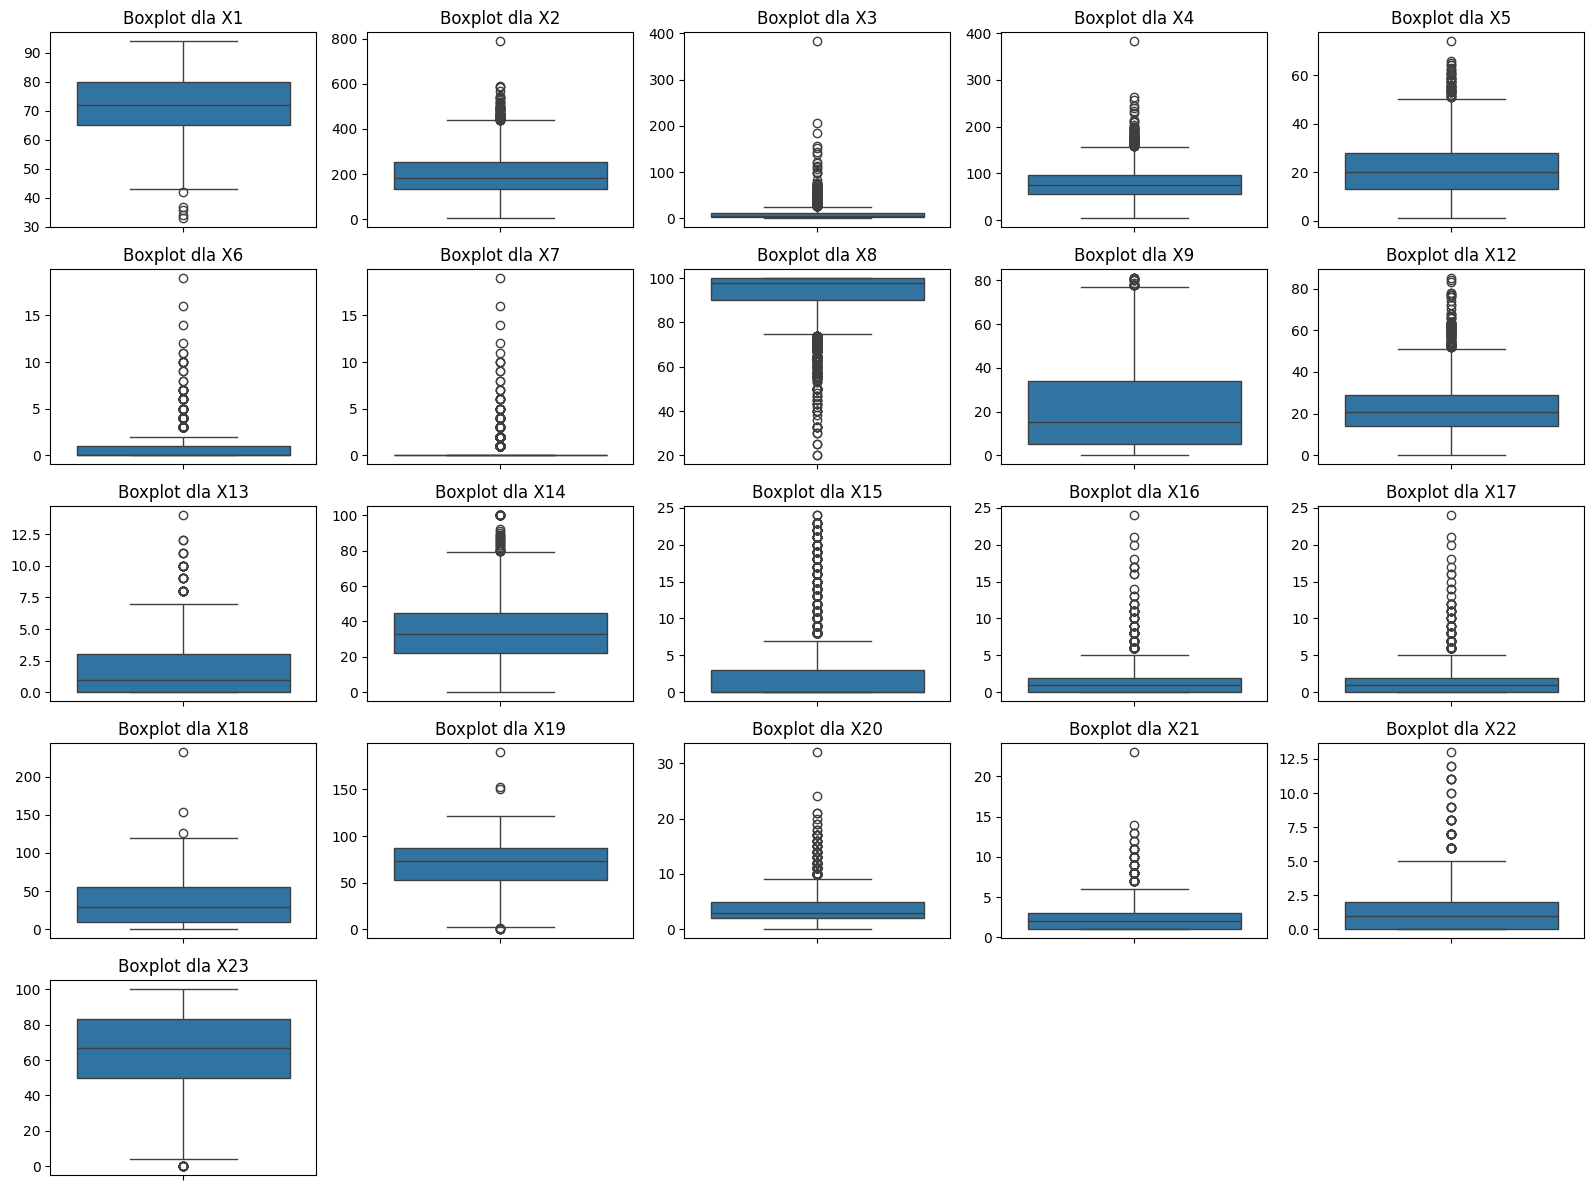

In [5]:
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns

# Plot boxplots
plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y=X[col])
    plt.ylabel('')
    plt.title(f'Boxplot dla {col}')
plt.tight_layout()
plt.show()

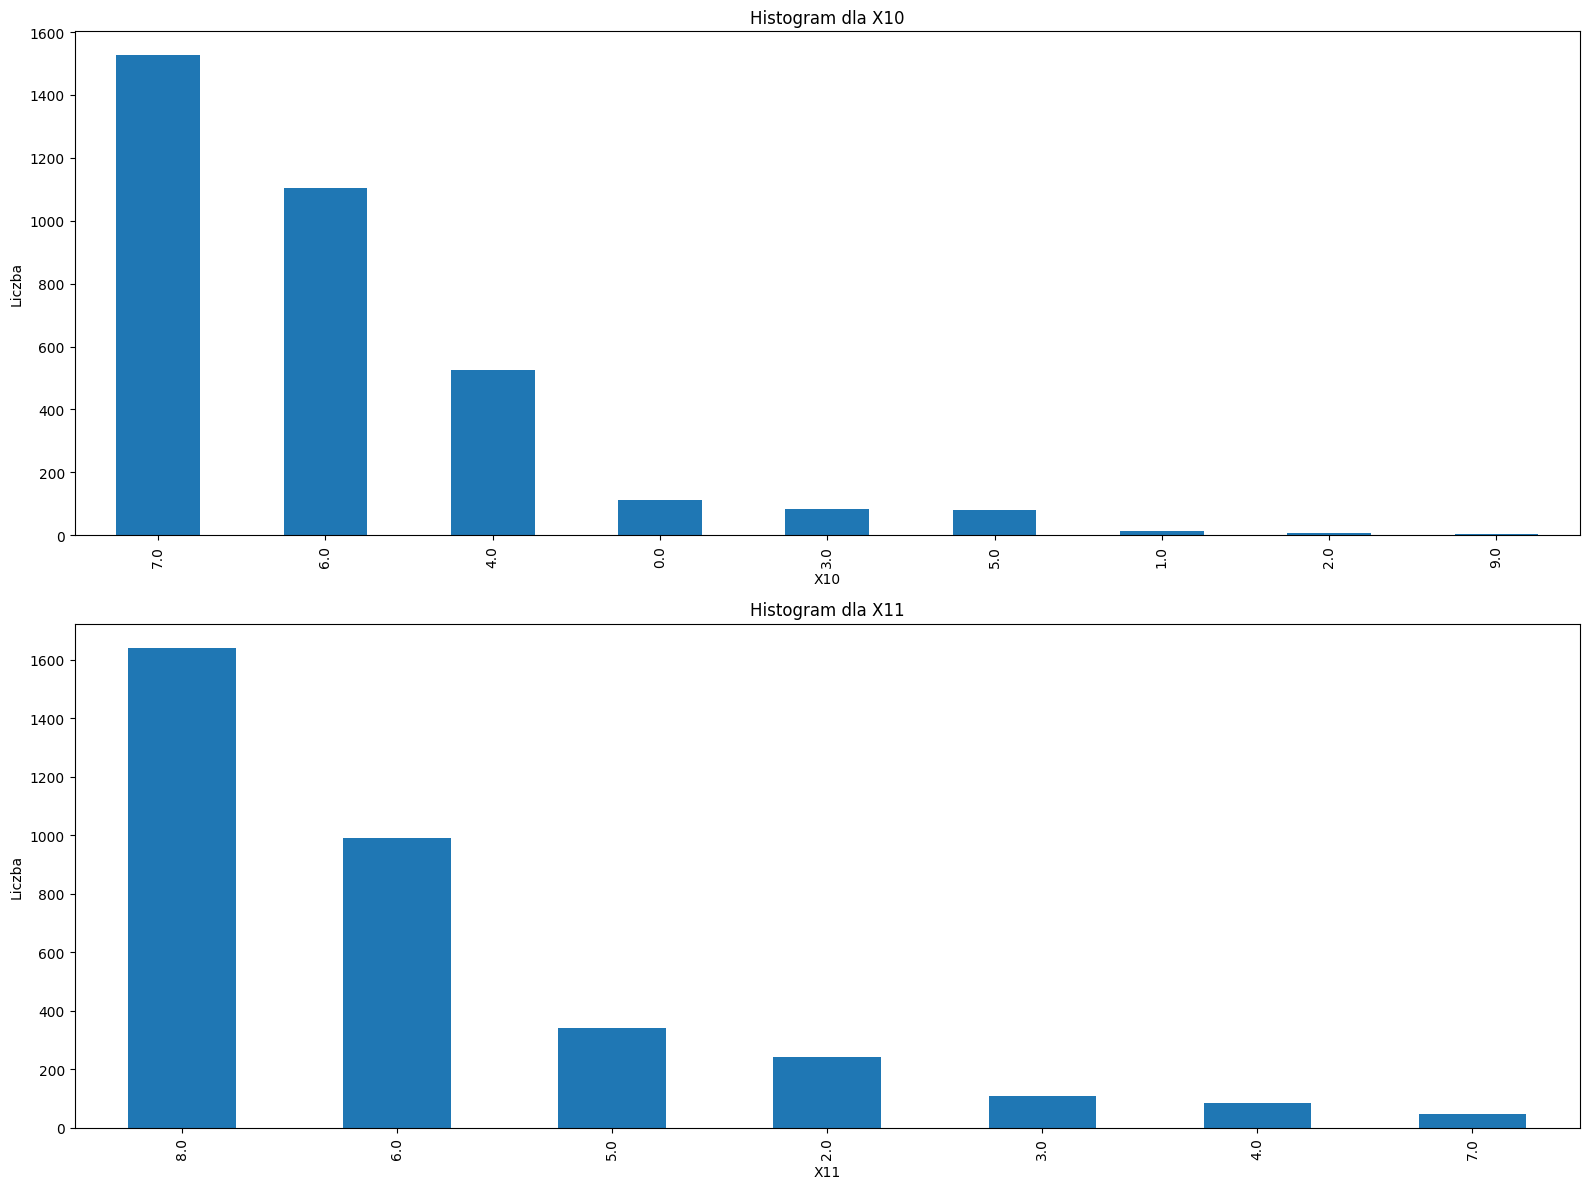

In [6]:
categorical_features = X.select_dtypes(include=['category']).columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 1, i)
    X[col].value_counts().plot(kind='bar')
    plt.title(f'Histogram dla {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba')
plt.tight_layout()
plt.show()

In [7]:
#Bez outlinerów
stats = pd.DataFrame(index=X.columns[1:], columns=['mean', 'variance', 'iqr', 'q1', 'median', 'q3'])

for col in X.columns[1:]:
    if X[col].dtype in ['float64', 'int64']:
        q1 = X[col].quantile(0.25)
        q3 = X[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        non_outliers = X[(X[col] >= lower_bound) & (X[col] <= upper_bound)][col]

        mean = non_outliers.mean()
        variance = non_outliers.var()
        median = non_outliers.median()

        stats.loc[col, 'mean'] = mean
        stats.loc[col, 'variance'] = variance
        stats.loc[col, 'iqr'] = iqr
        stats.loc[col, 'q1'] = q1
        stats.loc[col, 'median'] = median
        stats.loc[col, 'q3'] = q3

# Display the statistics
print(stats)


           mean     variance    iqr     q1 median     q3
X2   193.536079  8056.412382  122.0  133.0  182.0  255.0
X3     7.211904    32.961941    9.0    3.0    6.0   12.0
X4    75.775468   873.929962   40.0   57.0   75.0   97.0
X5    20.420065   109.221968   15.0   13.0   19.0   28.0
X6     0.340777     0.374044    1.0    0.0    0.0    1.0
X7          0.0          0.0    0.0    0.0    0.0    0.0
X8    95.312638    43.084446   10.0   90.0  100.0  100.0
X9    21.669817   398.952971   29.0    5.0   15.0   34.0
X10         NaN          NaN    NaN    NaN    NaN    NaN
X11         NaN          NaN    NaN    NaN    NaN    NaN
X12   21.445436   125.897304   15.0   14.0   20.0   29.0
X13    1.736765     2.606521    3.0    0.0    1.0    3.0
X14   33.743824   266.821968   23.0   22.0   33.0   45.0
X15    0.850237     2.756922    3.0    0.0    0.0    3.0
X16    1.214372     1.796136    2.0    0.0    1.0    2.0
X17    1.177898      1.76343    2.0    0.0    1.0    2.0
X18   34.427855   812.040027   

In [8]:
# Z outlinerami
stats = pd.DataFrame(index=X.columns[1:], columns=['mean', 'variance', 'iqr', 'q1', 'median', 'q3'])

for col in X.columns[1:]:
    if X[col].dtype in ['float64', 'int64']:
        q1 = X[col].quantile(0.25)
        q3 = X[col].quantile(0.75)
        iqr = q3 - q1

        mean = X[col].mean()
        variance = X[col].var()
        median = X[col].median()

        stats.loc[col, 'mean'] = mean
        stats.loc[col, 'variance'] = variance
        stats.loc[col, 'iqr'] = iqr
        stats.loc[col, 'q1'] = q1
        stats.loc[col, 'median'] = median
        stats.loc[col, 'q3'] = q3


print(stats)


           mean     variance    iqr     q1 median     q3
X2   198.727112  9463.378981  122.0  133.0  184.0  255.0
X3     9.958056   210.659409    9.0    3.0    6.0   12.0
X4    78.558866  1165.998342   40.0   57.0   76.0   97.0
X5    20.929997   126.481209   15.0   13.0   20.0   28.0
X6      0.57709     1.628966    1.0    0.0    0.0    1.0
X7     0.382123     1.105965    0.0    0.0    0.0    0.0
X8    92.538039    136.08138   10.0   90.0   98.0  100.0
X9    22.209479   426.064992   29.0    5.0   15.0   34.0
X10         NaN          NaN    NaN    NaN    NaN    NaN
X11         NaN          NaN    NaN    NaN    NaN    NaN
X12   22.530807   166.323197   15.0   14.0   21.0   29.0
X13    1.818629     3.204074    3.0    0.0    1.0    3.0
X14   34.718831    320.24731   23.0   22.0   33.0   45.0
X15    2.437618    22.470183    3.0    0.0    0.0    3.0
X16    1.485392     4.028215    2.0    0.0    1.0    2.0
X17    1.426092     3.840094    2.0    0.0    1.0    2.0
X18   34.548349   829.507541   

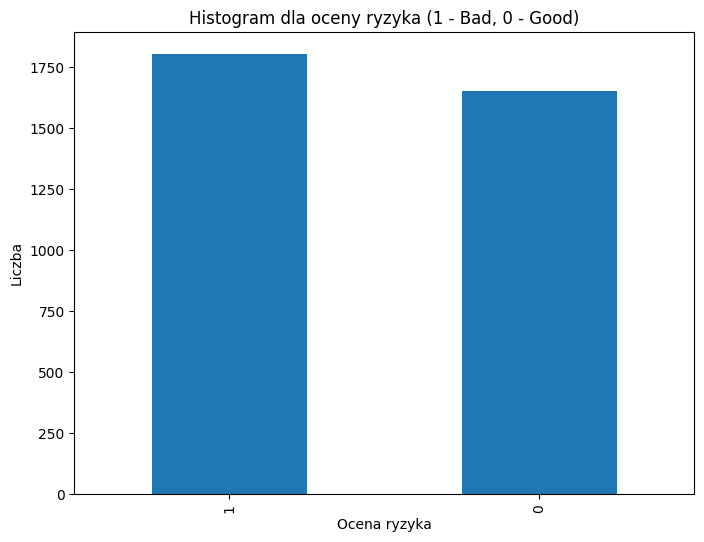

In [9]:
#Histogram dla y
plt.figure(figsize=(8, 6))
y['RiskPerformance'].value_counts().plot(kind='bar')
plt.xlabel('Ocena ryzyka')
plt.ylabel('Liczba')
plt.title('Histogram dla oceny ryzyka (1 - Bad, 0 - Good)')
plt.show()

Mamy w miarę równe proporcje, test size ustawiam na 80:20.

## Preprocessing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
kfold = skm.KFold(n_splits = 5, shuffle=True)

In [12]:
# PREPROCESSOR
categorical_features = list(X_train.dtypes[(X_train.dtypes == 'object') | (X_train.dtypes == 'category')].index)
numerical_features = list(X_train.dtypes[(X_train.dtypes != 'object') & (X_train.dtypes != 'category')].index)

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

numerical_transformer = Pipeline([
    ('scaler', StandardScaler())])

preprocessor = ColumnTransformer([
    ('onehot', categorical_transformer, categorical_features),
    ('scaler', numerical_transformer, numerical_features)])



## Proste modele

In [14]:
# Model drzewa decyzyjnego
pipeline_dt = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),  
    ('classifier', DecisionTreeClassifier())
])


# Model domyślny
pipeline_dt.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_dt_default = pipeline_dt.predict(X_test)
test_score_dt_default = balanced_accuracy_score(y_test, test_predictions_dt_default)
print('Wartość balanced accuracy dla drzewa decyzyjnego (domyślny model):', np.round(test_score_dt_default, 6))


param_grid_dt = {
    'classifier__max_depth': [2, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 7, 10, 12],
    'classifier__min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'classifier__criterion': ['gini', 'entropy']
}


grid_search_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_dt.fit(X_train, y_train.values.ravel())


print("Najlepsze parametry dla drzewa decyzyjnego:", grid_search_dt.best_params_)
print("Wynik score:", grid_search_dt.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_dt = grid_search_dt.predict(X_train)
train_score_dt = balanced_accuracy_score(y_train, train_predictions_dt)
print('Wartość balanced accuracy dla drzewa decyzyjnego:', np.round(train_score_dt, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_dt = grid_search_dt.predict(X_test)
test_score_dt = balanced_accuracy_score(y_test, test_predictions_dt)
print('Wartość balanced accuracy dla drzewa decyzyjnego na zbiorze testowym:', np.round(test_score_dt, 4))


grid_search_dt.best_estimator_

Wartość balanced accuracy dla drzewa decyzyjnego (domyślny model): 0.668359


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Najlepsze parametry dla drzewa decyzyjnego: {'classifier__criterion': 'entropy', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Wynik score: 0.7122535542880766
Wartość balanced accuracy dla drzewa decyzyjnego: 0.7128
Wartość balanced accuracy dla drzewa decyzyjnego na zbiorze testowym: 0.725


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=2))])

In [ ]:
#Model regresji logistycznej

pipeline_lr = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', LogisticRegression())
])


# Model domyślny
pipeline_lr.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym 
test_predictions_lr_default = pipeline_lr.predict(X_test)
test_score_lr_default = balanced_accuracy_score(y_test, test_predictions_lr_default)
print('Wartość balanced accuracy dla regresji logistycznej (domyślny model):', np.round(test_score_lr_default, 6))



param_grid_lr = [
    {  
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    { 
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': ['elasticnet'],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__l1_ratio': [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    },
    {  
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': [None],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__solver': ['lbfgs']
    }
]

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train.values.ravel())


print("Najlepsze parametry dla regresji logistycznej:", grid_search_lr.best_params_)
print("Wynik score:", grid_search_lr.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_lr = grid_search_lr.predict(X_train)
train_score_lr = balanced_accuracy_score(y_train, train_predictions_lr)
print('Wartość balanced accuracy dla regresji logistycznej:', np.round(train_score_lr, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_lr = grid_search_lr.predict(X_test)
test_score_lr = balanced_accuracy_score(y_test, test_predictions_lr)
print('Wartość balanced accuracy dla regresji logistycznej na zbiorze testowym:', np.round(test_score_lr, 4))


grid_search_lr.best_estimator_

Wartość balanced accuracy dla regresji logistycznej (domyślny model): 0.745528
Najlepsze parametry dla regresji logistycznej: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Wynik score: 0.7321478084893268
Wartość balanced accuracy dla regresji logistycznej: 0.7365
Wartość balanced accuracy dla regresji logistycznej na zbiorze testowym: 0.7373


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    solver='saga'))])

In [16]:
# Model lasu losowego

pipeline_rf = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', RandomForestClassifier())
])

# Model domyślny
pipeline_rf.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_rf_default = pipeline_rf.predict(X_test)
test_score_rf_default = balanced_accuracy_score(y_test, test_predictions_rf_default)
print('Wartość balanced accuracy dla lasu losowego (domyślny model):', np.round(test_score_rf_default, 6))



param_grid_rf = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4, 6, 8],
    'classifier__n_estimators': [50, 100, 200, 300, 400, 500]
}

grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla lasu losowego:", grid_search_rf.best_params_)
print("Wynik score:", grid_search_rf.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_rf = grid_search_rf.predict(X_train)
train_score_rf = balanced_accuracy_score(y_train, train_predictions_rf)
print('Wartość balanced accuracy dla lasu losowego:', np.round(train_score_rf, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_rf = grid_search_rf.predict(X_test)
test_score_rf = balanced_accuracy_score(y_test, test_predictions_rf)
print('Wartość balanced accuracy dla lasu losowego na zbiorze testowym:', np.round(test_score_rf, 4))


grid_search_rf.best_estimator_

Wartość balanced accuracy dla lasu losowego (domyślny model): 0.748544


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Najlepsze parametry dla lasu losowego: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Wynik score: 0.7367111634632242
Wartość balanced accuracy dla lasu losowego: 0.8176
Wartość balanced accuracy dla lasu losowego na zbiorze testowym: 0.7441


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=8))])

In [17]:
# Model kNN

pipeline_knn = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', KNeighborsClassifier())
])


# Model domyślny
pipeline_knn.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_knn_default = pipeline_knn.predict(X_test)
test_score_knn_default = balanced_accuracy_score(y_test, test_predictions_knn_default)
print('Wartość balanced accuracy dla kNN (domyślny model):', np.round(test_score_knn_default, 6))




param_grid_knn = {
    'classifier__n_neighbors': [2, 3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}

grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_knn.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla kNN:", grid_search_knn.best_params_)
print("Wynik score:", grid_search_knn.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_knn = grid_search_knn.predict(X_train)
train_score_knn = balanced_accuracy_score(y_train, train_predictions_knn)
print('Wartość balanced accuracy dla KNN:', np.round(train_score_knn, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_knn = grid_search_knn.predict(X_test)
test_score_knn = balanced_accuracy_score(y_test, test_predictions_knn)
print('Wartość balanced accuracy dla KNN na zbiorze testowym:', np.round(test_score_knn, 4))


grid_search_knn.best_estimator_


Wartość balanced accuracy dla kNN (domyślny model): 0.693828
Najlepsze parametry dla kNN: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Wynik score: 0.7004880972964395
Wartość balanced accuracy dla KNN: 0.7541
Wartość balanced accuracy dla KNN na zbiorze testowym: 0.7186


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=9))])

In [18]:
# Model SVM

pipeline_svm = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('classifier', SVC())
])

# Model domyślny
pipeline_svm.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym 
test_predictions_svm_default = pipeline_svm.predict(X_test)
test_score_svm_default = balanced_accuracy_score(y_test, test_predictions_svm_default)
print('Wartość balanced accuracy dla SVM (domyślny model):', np.round(test_score_svm_default, 6))



param_grid_svm = {
    'classifier__C': [0.1, 0.5, 1, 10, 20,100],
    'classifier__kernel': ['linear', 'rbf']
}

grid_search_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_svm.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla SVM:", grid_search_svm.best_params_)
print("Wynik score:", grid_search_svm.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_svm = grid_search_svm.predict(X_train)
train_score_svm = balanced_accuracy_score(y_train, train_predictions_svm)
print('Wartość balanced accuracy dla SVM:', np.round(train_score_svm, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_svm = grid_search_svm.predict(X_test)
test_score_svm = balanced_accuracy_score(y_test, test_predictions_svm)
print('Wartość balanced accuracy dla SVM na zbiorze testowym:', np.round(test_score_svm, 4))


grid_search_svm.best_estimator_

Wartość balanced accuracy dla SVM (domyślny model): 0.741171
Najlepsze parametry dla SVM: {'classifier__C': 0.5, 'classifier__kernel': 'rbf'}
Wynik score: 0.73066595411929
Wartość balanced accuracy dla SVM: 0.7585
Wartość balanced accuracy dla SVM na zbiorze testowym: 0.7468


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()), ('classifier', SVC(C=0.5))])

## Złożone modele na podstawie drzew decyzyjnych

In [20]:
# Model ExtraTreeClassifier
pipeline_extra = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),  
    ('classifier', ExtraTreesClassifier())
])


# Model domyślny
pipeline_extra.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_extra_default = pipeline_extra.predict(X_test)
test_score_extra_default = balanced_accuracy_score(y_test, test_predictions_extra_default)
print('Wartość balanced accuracy dla ExtraTreeClassifier (domyślny model):', np.round(test_score_extra_default, 6))



param_grid_extra = {
    'classifier__n_estimators': [20, 50, 100, 200, 300],
    'classifier__max_depth': [None, 2, 5, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4, 6],
    'classifier__bootstrap': [True]
}



grid_search_extra = GridSearchCV(pipeline_extra, param_grid_extra, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_extra.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla ExtraTreeClassifier:", grid_search_extra.best_params_)
print("Wynik score:", grid_search_extra.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_extra = grid_search_extra.predict(X_train)
train_score_extra = balanced_accuracy_score(y_train, train_predictions_extra)
print('Wartość balanced accuracy dla Extra Trees:', np.round(train_score_extra, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_extra = grid_search_extra.predict(X_test)
test_score_extra = balanced_accuracy_score(y_test, test_predictions_extra)
print('Wartość balanced accuracy dla Extra Trees na zbiorze testowym:', np.round(test_score_extra, 4))


grid_search_extra.best_estimator_


Wartość balanced accuracy dla ExtraTreeClassifier (domyślny model): 0.743978
Najlepsze parametry dla ExtraTreeClassifier: {'classifier__bootstrap': True, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Wynik score: 0.7219852127860424
Wartość balanced accuracy dla Extra Trees: 0.9141
Wartość balanced accuracy dla Extra Trees na zbiorze testowym: 0.7367


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 ExtraTreesClassifier(bootstrap=True, min_samples_leaf=2))])

In [48]:
# Model GradientBoostingClassifier
pipeline_gradient = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),  
    ('classifier', GradientBoostingClassifier())
])


# Model domyślny
pipeline_gradient.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_gradient_default = pipeline_gradient.predict(X_test)
test_score_gradient_default = balanced_accuracy_score(y_test, test_predictions_gradient_default)
print('Wartość balanced accuracy dla Gradient Boosting (domyślny model):', np.round(test_score_gradient_default, 6))


#Parametry zostały znacząco ograniczone przez złożoność obliczeniową
param_grid_gradient = {
    'classifier__n_estimators': [20, 50, 100, 200, 300],  
    'classifier__max_depth': [2, 3, 5, 7], 
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4, 6]
}



grid_search_gradient = GridSearchCV(pipeline_gradient, param_grid_gradient, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_gradient.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla GradientBoostingClassifier:", grid_search_gradient.best_params_)
print("Wynik score:", grid_search_gradient.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_gradient = grid_search_gradient.predict(X_train)
train_score_gradient = balanced_accuracy_score(y_train, train_predictions_gradient)
print('Wartość balanced accuracy dla Gradient Boosting:', np.round(train_score_gradient, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_gradient = grid_search_gradient.predict(X_test)
test_score_gradient = balanced_accuracy_score(y_test, test_predictions_gradient)
print('Wartość balanced accuracy dla Gradient Boosting na zbiorze testowym:', np.round(test_score_gradient, 4))


grid_search_gradient.best_estimator_


Wartość balanced accuracy dla Gradient Boosting (domyślny model): 0.745779
Najlepsze parametry dla GradientBoostingClassifier: {'classifier__max_depth': 2, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Wynik score: 0.7308040564591245
Wartość balanced accuracy dla Gradient Boosting: 0.7515
Wartość balanced accuracy dla Gradient Boosting na zbiorze testowym: 0.7457


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('classifier',
                 GradientBoostingClassifier(max_depth=2, min_samples_leaf=6,
                                            n_estimators=50))])

In [ ]:
# Model AdaBoostClassifier
pipeline_adaboost = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=3)),  
    ('classifier', AdaBoostClassifier())
])


# Model domyślny
pipeline_adaboost.fit(X_train, y_train.values.ravel())

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_adaboost_default = pipeline_adaboost.predict(X_test)
test_score_adaboost_default = balanced_accuracy_score(y_test, test_predictions_adaboost_default)
print('Wartość balanced accuracy dla AdaBoost (domyślny model):', np.round(test_score_adaboost_default, 6))



param_grid_adaboost = {
    'classifier__n_estimators': [20, 50, 100, 200, 300, 500],  
    'classifier__algorithm': ['SAMME'],  
    'classifier__estimator': [  
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=3),
        DecisionTreeClassifier(max_depth=5)
    ]
}


grid_search_adaboost = GridSearchCV(pipeline_adaboost, param_grid_adaboost, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_adaboost.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla AdaBoostClassifier:", grid_search_adaboost.best_params_)
print("Wynik score:", grid_search_adaboost.best_score_)


# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_adaboost = grid_search_adaboost.predict(X_train)
train_score_adaboost = balanced_accuracy_score(y_train, train_predictions_adaboost)
print('Wartość balanced accuracy dla AdaBoost:', np.round(train_score_adaboost, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_adaboost = grid_search_adaboost.predict(X_test)
test_score_adaboost = balanced_accuracy_score(y_test, test_predictions_adaboost)
print('Wartość balanced accuracy dla AdaBoost na zbiorze testowym:', np.round(test_score_adaboost, 4))


grid_search_adaboost.best_estimator_


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Wartość balanced accuracy dla AdaBoost (domyślny model): 0.760107
Najlepsze parametry dla AdaBoostClassifier: {'classifier__algorithm': 'SAMME', 'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__n_estimators': 200}
Wynik score: 0.7254279265099578
Wartość balanced accuracy dla AdaBoost: 0.7391
Wartość balanced accuracy dla AdaBoost na zbiorze testowym: 0.7657


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer(n_neighbors=3)),
                ('classifier',
                 AdaBoostClassifier(algorithm='SAMME',
                                    estimator=DecisionTreeClassifier(max_depth=1),
                                    n_estimators=200))])

## Bagging na prostych modelach

Bagging będę wykonywać na Decision Tree, Logistic Regression, KNN, SVM (domyślne oraz z zoptymalizowanymi hiperparametrami)

In [23]:
params_bagging = {
    'bagging__n_estimators': [20, 50, 100, 150, 200, 300]
}

### Decision Tree

In [24]:

# Bagging DecisionTreeClassifier domyślny
pipeline_bagging_dt_default = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=DecisionTreeClassifier()))
])


grid_search_bagging_dt_default = GridSearchCV(pipeline_bagging_dt_default, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_dt_default.fit(X_train, y_train)

print("Najlepsze parametry dla BaggingClassifier (DecisionTree):", grid_search_bagging_dt_default.best_params_)
print("Wynik score:", grid_search_bagging_dt_default.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_dt_default = grid_search_bagging_dt_default.predict(X_train)
train_score_bagging_dt_default = balanced_accuracy_score(y_train, train_predictions_bagging_dt_default)
print('Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) domyślne:', np.round(train_score_bagging_dt_default, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_dt_default = grid_search_bagging_dt_default.predict(X_test)
test_score_bagging_dt_default = balanced_accuracy_score(y_test, test_predictions_bagging_dt_default)
print('Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) domyślne na zbiorze testowym:', np.round(test_score_bagging_dt_default, 4))


grid_search_bagging_dt_default.best_estimator_


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_bagging.py:888: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Najlepsze parametry dla BaggingClassifier (DecisionTree): {'bagging__n_estimators': 150}
Wynik score: 0.7177360424013591
Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) domyślne: 1.0
Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) domyślne na zbiorze testowym: 0.7556


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=DecisionTreeClassifier(),
                                   n_estimators=150))])

In [25]:
# Bagging DecisionTreeClassifier z parametrami
best_dt = grid_search_dt.best_estimator_
pipeline_bagging_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=grid_search_dt.best_estimator_['classifier']))
])


grid_search_bagging_dt = GridSearchCV(pipeline_bagging_dt, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_dt.fit(X_train, y_train)

print("Najlepsze parametry dla BaggingClassifier (DecisionTree):", grid_search_bagging_dt.best_params_)
print("Wynik score:", grid_search_bagging_dt.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_dt = grid_search_bagging_dt.predict(X_train)
train_score_bagging_dt = balanced_accuracy_score(y_train, train_predictions_bagging_dt)
print('Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne):', np.round(train_score_bagging_dt, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_dt = grid_search_bagging_dt.predict(X_test)
test_score_bagging_dt = balanced_accuracy_score(y_test, test_predictions_bagging_dt)
print('Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) na zbiorze testowym:', np.round(test_score_bagging_dt, 4))


grid_search_bagging_dt.best_estimator_


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_bagging.py:888: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Najlepsze parametry dla BaggingClassifier (DecisionTree): {'bagging__n_estimators': 300}
Wynik score: 0.7087793864973004
Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne): 0.7128
Wartość balanced accuracy dla Bagging (Drzewo Decyzyjne) na zbiorze testowym: 0.725


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                                    max_depth=2),
                                   n_estimators=300))])

### Logistic Regression

In [26]:
# Bagging LogisticRegression domyślny
pipeline_bagging_lr_default = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=LogisticRegression()))
])


grid_search_bagging_lr_default = GridSearchCV(pipeline_bagging_lr_default, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_lr_default.fit(X_train, y_train)

print("Najlepsze parametry dla BaggingClassifier (LogisticRegression):", grid_search_bagging_lr_default.best_params_)
print("Wynik score:", grid_search_bagging_lr_default.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_lr_default = grid_search_bagging_lr_default.predict(X_train)
train_score_bagging_lr_default = balanced_accuracy_score(y_train, train_predictions_bagging_lr_default)
print('Wartość balanced accuracy dla Bagging (LogisticRegression) domyślne:', np.round(train_score_bagging_lr_default, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_lr_default = grid_search_bagging_lr_default.predict(X_test)
test_score_bagging_lr_default = balanced_accuracy_score(y_test, test_predictions_bagging_lr_default)
print('Wartość balanced accuracy dla Bagging (LogisticRegression) domyślne na zbiorze testowym:', np.round(test_score_bagging_lr_default, 4))

grid_search_bagging_lr_default.best_estimator_


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_bagging.py:888: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Najlepsze parametry dla BaggingClassifier (LogisticRegression): {'bagging__n_estimators': 300}
Wynik score: 0.7283849160372041
Wartość balanced accuracy dla Bagging (LogisticRegression) domyślne: 0.7336
Wartość balanced accuracy dla Bagging (LogisticRegression) domyślne na zbiorze testowym: 0.7455


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=LogisticRegression(),
                                   n_estimators=300))])

In [27]:
# Bagging LogisticRegression z parametrami
pipeline_bagging_lr = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=grid_search_lr.best_estimator_['classifier']))
])


grid_search_bagging_lr = GridSearchCV(pipeline_bagging_lr, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_lr.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla BaggingClassifier (LogisticRegression):", grid_search_bagging_lr.best_params_)
print("Wynik score:", grid_search_bagging_lr.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_lr = grid_search_bagging_lr.predict(X_train)
train_score_bagging_lr = balanced_accuracy_score(y_train, train_predictions_bagging_lr)
print('Wartość balanced accuracy dla Bagging (Logistic Regression):', np.round(train_score_bagging_lr, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_lr = grid_search_bagging_lr.predict(X_test)
test_score_bagging_lr = balanced_accuracy_score(y_test, test_predictions_bagging_lr)
print('Wartość balanced accuracy dla Bagging (Logistic Regression) na zbiorze testowym:', np.round(test_score_bagging_lr, 4))


grid_search_bagging_lr.best_estimator_


c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the 

Najlepsze parametry dla BaggingClassifier (LogisticRegression): {'bagging__n_estimators': 300}
Wynik score: 0.7328023970191191
Wartość balanced accuracy dla Bagging (Logistic Regression): 0.7365
Wartość balanced accuracy dla Bagging (Logistic Regression) na zbiorze testowym: 0.7373


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=LogisticRegression(C=0.01,
                                                                class_weight='balanced',
                                                                solver='saga'),
                                   n_estimators=300))])

### KNN

In [28]:
# Bagging KNeighborsClassifier domyślny
pipeline_bagging_knn_default = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=KNeighborsClassifier()))
])



grid_search_bagging_knn_default = GridSearchCV(pipeline_bagging_knn_default,params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_knn_default.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla BaggingClassifier (KNeighborsClassifier):", grid_search_bagging_knn_default.best_params_)
print("Wynik score:", grid_search_bagging_knn_default.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_knn_default = grid_search_bagging_knn_default.predict(X_train)
train_score_bagging_knn_default = balanced_accuracy_score(y_train, train_predictions_bagging_knn_default)
print('Wartość balanced accuracy dla Bagging (KNeighborsClassifier) domyślne:', np.round(train_score_bagging_knn_default, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_knn_default = grid_search_bagging_knn_default.predict(X_test)
test_score_bagging_knn_default = balanced_accuracy_score(y_test, test_predictions_bagging_knn_default)
print('Wartość balanced accuracy dla Bagging (KNeighborsClassifier) domyślne na zbiorze testowym:', np.round(test_score_bagging_knn_default, 4))

grid_search_bagging_knn_default.best_estimator_


Najlepsze parametry dla BaggingClassifier (KNeighborsClassifier): {'bagging__n_estimators': 50}
Wynik score: 0.6898245776580659
Wartość balanced accuracy dla Bagging (KNeighborsClassifier) domyślne: 0.7856
Wartość balanced accuracy dla Bagging (KNeighborsClassifier) domyślne na zbiorze testowym: 0.7096


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=KNeighborsClassifier(),
                                   n_estimators=50))])

In [29]:
# Bagging kNN z parametrami
pipeline_bagging_knn = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=grid_search_knn.best_estimator_['classifier']))
])



grid_search_bagging_knn = GridSearchCV(pipeline_bagging_knn, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_knn.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla BaggingClassifier (kNN):", grid_search_bagging_knn.best_params_)
print("Wynik score:", grid_search_bagging_knn.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_knn = grid_search_bagging_knn.predict(X_train)
train_score_bagging_knn = balanced_accuracy_score(y_train, train_predictions_bagging_knn)
print('Wartość balanced accuracy dla Bagging (KNN):', np.round(train_score_bagging_knn, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_knn = grid_search_bagging_knn.predict(X_test)
test_score_bagging_knn = balanced_accuracy_score(y_test, test_predictions_bagging_knn)
print('Wartość balanced accuracy dla Bagging (KNN) na zbiorze testowym:', np.round(test_score_bagging_knn, 4))



grid_search_bagging_knn.best_estimator_


Najlepsze parametry dla BaggingClassifier (kNN): {'bagging__n_estimators': 200}
Wynik score: 0.6968030581083647
Wartość balanced accuracy dla Bagging (KNN): 0.7558
Wartość balanced accuracy dla Bagging (KNN) na zbiorze testowym: 0.7288


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=KNeighborsClassifier(metric='euclidean',
                                                                  n_neighbors=9),
                                   n_estimators=200))])

### SVM

In [30]:
# Bagging SVC (Support Vector Classifier) domyślny
pipeline_bagging_svm_default = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=SVC()))
])



grid_search_bagging_svm_default = GridSearchCV(pipeline_bagging_svm_default, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_svm_default.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla BaggingClassifier (SVC):", grid_search_bagging_svm_default.best_params_)
print("Wynik score:", grid_search_bagging_svm_default.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_svm_default = grid_search_bagging_svm_default.predict(X_train)
train_score_bagging_svm_default = balanced_accuracy_score(y_train, train_predictions_bagging_svm_default)
print('Wartość balanced accuracy dla Bagging (SVC) domyślne:', np.round(train_score_bagging_svm_default, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_svm_default = grid_search_bagging_svm_default.predict(X_test)
test_score_bagging_svm_default = balanced_accuracy_score(y_test, test_predictions_bagging_svm_default)
print('Wartość balanced accuracy dla Bagging (SVC) domyślne na zbiorze testowym:', np.round(test_score_bagging_svm_default, 4))

grid_search_bagging_svm_default.best_estimator_


Najlepsze parametry dla BaggingClassifier (SVC): {'bagging__n_estimators': 50}
Wynik score: 0.7356127046411677
Wartość balanced accuracy dla Bagging (SVC) domyślne: 0.7824
Wartość balanced accuracy dla Bagging (SVC) domyślne na zbiorze testowym: 0.7384


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=SVC(), n_estimators=50))])

In [31]:
# Bagging SVM
pipeline_bagging_svm = Pipeline([
    ('pre', preprocessor),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('bagging', BaggingClassifier(estimator=grid_search_svm.best_estimator_['classifier']))
])



grid_search_bagging_svm = GridSearchCV(pipeline_bagging_svm, params_bagging, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)
grid_search_bagging_svm.fit(X_train, y_train.values.ravel())

print("Najlepsze parametry dla BaggingClassifier (SVM):", grid_search_bagging_svm.best_params_)
print("Wynik score:", grid_search_bagging_svm.best_score_)

# Oblicz i wyświetl balanced accuracy modelu na zbiorze treningowym
train_predictions_bagging_svm = grid_search_bagging_svm.predict(X_train)
train_score_bagging_svm = balanced_accuracy_score(y_train, train_predictions_bagging_svm)
print('Wartość balanced accuracy dla Bagging (SVM):', np.round(train_score_bagging_svm, 4))

# Oblicz i wyświetl balanced accuracy modelu na zbiorze testowym
test_predictions_bagging_svm = grid_search_bagging_svm.predict(X_test)
test_score_bagging_svm = balanced_accuracy_score(y_test, test_predictions_bagging_svm)
print('Wartość balanced accuracy dla Bagging (SVM) na zbiorze testowym:', np.round(test_score_bagging_svm, 4))

grid_search_bagging_svm.best_estimator_


Najlepsze parametry dla BaggingClassifier (SVM): {'bagging__n_estimators': 20}
Wynik score: 0.7266114006023553
Wartość balanced accuracy dla Bagging (SVM): 0.7621
Wartość balanced accuracy dla Bagging (SVM) na zbiorze testowym: 0.7485


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('bagging',
                 BaggingClassifier(estimator=SVC(C=0.5), n_estimators=20))])

## Wyniki prostych, złożonych modeli i bagging

Zebranie wszystkich wyników do ramek danych

In [63]:
models = [
    pipeline_dt,
    pipeline_lr, 
    pipeline_rf,  
    pipeline_knn,  
    pipeline_svm,  
    pipeline_extra,  
    pipeline_gradient,  
    pipeline_adaboost  
]

model_names = [
    'Decision Tree (Default)', 
    'Logistic Regression (Default)',
    'Random Forest (Default)', 
    'KNN (Default)',  
    'SVM (Default)', 
    'Extra Trees (Default)', 
    'Gradient Boosting (Default)', 
    'AdaBoost (Default)'
]

train_accuracies = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models
]

test_accuracies = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models
]

result_default_df = pd.DataFrame({
    'Model': model_names,
    'Balanced Accuracy Train (Default)': train_accuracies,
    'Balanced Accuracy Test (Default)': test_accuracies
})

result_default_df['Balanced Accuracy Train (Default)'] = result_default_df['Balanced Accuracy Train (Default)'].round(4)
result_default_df['Balanced Accuracy Test (Default)'] = result_default_df['Balanced Accuracy Test (Default)'].round(4)

print(result_default_df)


                           Model  Balanced Accuracy Train (Default)  \
0        Decision Tree (Default)                             1.0000   
1  Logistic Regression (Default)                             0.7329   
2        Random Forest (Default)                             1.0000   
3                  KNN (Default)                             0.7748   
4                  SVM (Default)                             0.7763   
5          Extra Trees (Default)                             1.0000   
6    Gradient Boosting (Default)                             0.7918   
7             AdaBoost (Default)                             0.7522   

   Balanced Accuracy Test (Default)  
0                            0.6684  
1                            0.7455  
2                            0.7485  
3                            0.6938  
4                            0.7412  
5                            0.7440  
6                            0.7458  
7                            0.7601  


In [64]:

# Lista modeli i ich nazw 
models = [   
    grid_search_dt,
    grid_search_lr, 
    grid_search_rf, 
    grid_search_knn,  
    grid_search_svm, 
    grid_search_extra, 
    grid_search_gradient, 
    grid_search_adaboost
]

model_names = [
    'Decision Tree',
    'Logistic Regression', 
    'Random Forest', 
    'KNN',  
    'SVM', 
    'Extra Trees', 
    'Gradient Boosting', 
    'AdaBoost'
]

# Obliczanie Balanced Accuracy dla treningowego i testowego
train_accuracies = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models
]

test_accuracies = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models
]

# Tworzenie DataFrame z wynikami
results_df = pd.DataFrame({
    'Model': model_names,
    'Balanced Accuracy Train': train_accuracies,
    'Balanced Accuracy Test': test_accuracies
})

results_df['Balanced Accuracy Train'] = results_df['Balanced Accuracy Train'].round(4)
results_df['Balanced Accuracy Test'] = results_df['Balanced Accuracy Test'].round(4)

# Wyświetlanie wyników
print(results_df)


                 Model  Balanced Accuracy Train  Balanced Accuracy Test
0        Decision Tree                   0.7128                  0.7250
1  Logistic Regression                   0.7365                  0.7373
2        Random Forest                   0.8176                  0.7441
3                  KNN                   0.7541                  0.7186
4                  SVM                   0.7585                  0.7468
5          Extra Trees                   0.9141                  0.7367
6    Gradient Boosting                   0.7515                  0.7457
7             AdaBoost                   0.7391                  0.7657


In [65]:


# Lista modeli z baggingiem i ich nazw 
models_bagging = [
    grid_search_bagging_dt,
    grid_search_bagging_lr, 
    grid_search_bagging_knn,  
    grid_search_bagging_svm, 
]

model_names_bagging = [
    'Decision Tree (Bagging)', 
    'Logistic Regression (Bagging)', 
    'KNN (Bagging)',  
    'SVM (Bagging)'
]

# Obliczanie Balanced Accuracy dla treningowego i testowego
train_accuracies_bagging = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models_bagging
]

test_accuracies_bagging = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models_bagging
]

# Tworzenie DataFrame z wynikami
result_bagging_df = pd.DataFrame({
    'Model': model_names_bagging,
    'Balanced Accuracy Train (Bagging)': train_accuracies_bagging,
    'Balanced Accuracy Test (Bagging)': test_accuracies_bagging
})


result_bagging_df['Balanced Accuracy Train (Bagging)'] = result_bagging_df['Balanced Accuracy Train (Bagging)'].round(4)
result_bagging_df['Balanced Accuracy Test (Bagging)'] = result_bagging_df['Balanced Accuracy Test (Bagging)'].round(4)

# Wyświetlanie wyników
print(result_bagging_df)


                           Model  Balanced Accuracy Train (Bagging)  \
0        Decision Tree (Bagging)                             0.7128   
1  Logistic Regression (Bagging)                             0.7365   
2                  KNN (Bagging)                             0.7558   
3                  SVM (Bagging)                             0.7621   

   Balanced Accuracy Test (Bagging)  
0                            0.7250  
1                            0.7373  
2                            0.7288  
3                            0.7485  


In [66]:
models_bagging_default = [
    grid_search_bagging_dt_default, 
    grid_search_bagging_lr_default, 
    grid_search_bagging_knn_default,  
    grid_search_bagging_svm_default 
]

model_names_bagging_default = [
    'Decision Tree (Bagging Default)', 
    'Logistic Regression (Bagging Default)', 
    'KNN (Bagging Default)',  
    'SVM (Bagging Default)'
]

train_accuracies_bagging_default = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models_bagging_default
]

test_accuracies_bagging_default = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models_bagging_default
]


result_bagging_default_df = pd.DataFrame({
    'Model': model_names_bagging_default,
    'Balanced Accuracy Train (Bagging Default)': train_accuracies_bagging_default,
    'Balanced Accuracy Test (Bagging Default)': test_accuracies_bagging_default
})

result_bagging_default_df['Balanced Accuracy Train (Bagging Default)'] = result_bagging_default_df['Balanced Accuracy Train (Bagging Default)'].round(4)
result_bagging_default_df['Balanced Accuracy Test (Bagging Default)'] = result_bagging_default_df['Balanced Accuracy Test (Bagging Default)'].round(4)

print(result_bagging_default_df)


                                   Model  \
0        Decision Tree (Bagging Default)   
1  Logistic Regression (Bagging Default)   
2                  KNN (Bagging Default)   
3                  SVM (Bagging Default)   

   Balanced Accuracy Train (Bagging Default)  \
0                                     1.0000   
1                                     0.7336   
2                                     0.7856   
3                                     0.7824   

   Balanced Accuracy Test (Bagging Default)  
0                                    0.7556  
1                                    0.7455  
2                                    0.7096  
3                                    0.7384  


In [67]:
final_results_df = pd.concat([result_default_df, results_df.iloc[:, 1:3]], axis =1 )
print(final_results_df)

                           Model  Balanced Accuracy Train (Default)  \
0        Decision Tree (Default)                             1.0000   
1  Logistic Regression (Default)                             0.7329   
2        Random Forest (Default)                             1.0000   
3                  KNN (Default)                             0.7748   
4                  SVM (Default)                             0.7763   
5          Extra Trees (Default)                             1.0000   
6    Gradient Boosting (Default)                             0.7918   
7             AdaBoost (Default)                             0.7522   

   Balanced Accuracy Test (Default)  Balanced Accuracy Train  \
0                            0.6684                   0.7128   
1                            0.7455                   0.7365   
2                            0.7485                   0.8176   
3                            0.6938                   0.7541   
4                            0.7412     

In [68]:
final_results_bagging_df = pd.concat([result_bagging_default_df, result_bagging_df.iloc[:, 1:3]], axis =1 )
print(final_results_bagging_df)

                                   Model  \
0        Decision Tree (Bagging Default)   
1  Logistic Regression (Bagging Default)   
2                  KNN (Bagging Default)   
3                  SVM (Bagging Default)   

   Balanced Accuracy Train (Bagging Default)  \
0                                     1.0000   
1                                     0.7336   
2                                     0.7856   
3                                     0.7824   

   Balanced Accuracy Test (Bagging Default)  \
0                                    0.7556   
1                                    0.7455   
2                                    0.7096   
3                                    0.7384   

   Balanced Accuracy Train (Bagging)  Balanced Accuracy Test (Bagging)  
0                             0.7128                            0.7250  
1                             0.7365                            0.7373  
2                             0.7558                            0.7288  
3         

## Voting, stacking

In [55]:
estimators5 = [
    ('dt', grid_search_dt.best_estimator_.named_steps['classifier']),
    ('rl', grid_search_lr.best_estimator_.named_steps['classifier']),
    ('rf', grid_search_rf.best_estimator_.named_steps['classifier']),
    ('knn', grid_search_knn.best_estimator_.named_steps['classifier']),
    ('svm', grid_search_svm.best_estimator_.named_steps['classifier'])
]

In [56]:
estimators3 = [
    ('extra', grid_search_extra.best_estimator_.named_steps['classifier']),
    ('gradient', grid_search_gradient.best_estimator_.named_steps['classifier']),
    ('adaboost', grid_search_adaboost.best_estimator_.named_steps['classifier'])
]

In [57]:
estimatorsb = [
    ('dtb', grid_search_bagging_dt.best_estimator_.named_steps['bagging']),
    ('rlb', grid_search_bagging_lr.best_estimator_.named_steps['bagging']),
    ('knnb', grid_search_bagging_knn.best_estimator_.named_steps['bagging']),
    ('svmb', grid_search_bagging_svm.best_estimator_.named_steps['bagging'])
]

In [70]:
# Stacking dt lr rd knn svm
estimators5 = [
    ('dt', grid_search_dt.best_estimator_.named_steps['classifier']),
    ('rl', grid_search_lr.best_estimator_.named_steps['classifier']),
    ('rf', grid_search_rf.best_estimator_.named_steps['classifier']),
    ('knn', grid_search_knn.best_estimator_.named_steps['classifier']),
    ('svm', grid_search_svm.best_estimator_.named_steps['classifier'])
]


stacking_5_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)), 
                           ('model', StackingClassifier(estimators=estimators5, final_estimator=LogisticRegression(), 
                                                        stack_method='predict'))
                           ])

stacking_5_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_stacking_5 = stacking_5_pipeline.predict(X_train)
train_score_stacking_5 = balanced_accuracy_score(y_train, train_predictions_stacking_5)
print('Balanced accuracy score on the train set:', np.round(train_score_stacking_5, 4))

test_predictions_stacking_5 = stacking_5_pipeline.predict(X_test)
test_score_stacking_5 = balanced_accuracy_score(y_test, test_predictions_stacking_5)
print('Balanced accuracy score on the test set:', np.round(test_score_stacking_5, 4))

stacking_5_pipeline

Balanced accuracy score on the train set: 0.7447
Balanced accuracy score on the test set: 0.7385


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KN...
                 StackingClassifier(estimators=[('dt',
                                                 DecisionTreeClassifier(criterion='entropy',
                                                                        max_depth=2)),
                                                ('rl',
                                                 LogisticRegression(C=0.01,
                                                                    class_weight='balanced',
                                                                    solver='saga')),
                                                ('rf',
                                                 RandomForestClassifier(max_depth=10,
                                                                        min_samples_leaf=8)),
                                                ('knn',
                                                 KNeighborsClassifier(metric='euclidean',
                                                                      n_neighbors=9)),
                                                ('svm', SVC(C=0.5))],
                                    final_estimator=LogisticRegression(),
                                    stack_method='predict'))])

In [71]:
#Stacking extra, gradient, adaboost

estimators3 = [
    ('extra', grid_search_extra.best_estimator_.named_steps['classifier']),
    ('gradient', grid_search_gradient.best_estimator_.named_steps['classifier']),
    ('adaboost', grid_search_adaboost.best_estimator_.named_steps['classifier'])
]

stacking_3_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)), 
                           ('model', StackingClassifier(estimators=estimators3, final_estimator=LogisticRegression(), 
                                                        stack_method='predict'))
                           ])

stacking_3_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_stacking_3 = stacking_3_pipeline.predict(X_train)
train_score_stacking_3 = balanced_accuracy_score(y_train, train_predictions_stacking_3)
print('Balanced accuracy score on the train set:', np.round(train_score_stacking_3, 4))

test_predictions_stacking_3 = stacking_3_pipeline.predict(X_test)
test_score_stacking_3 = balanced_accuracy_score(y_test, test_predictions_stacking_3)
print('Balanced accuracy score on the test set:', np.round(test_score_stacking_3, 4))

stacking_3_pipeline

Balanced accuracy score on the train set: 0.7756
Balanced accuracy score on the test set: 0.7485


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KN...
                 StackingClassifier(estimators=[('extra',
                                                 ExtraTreesClassifier(bootstrap=True,
                                                                      min_samples_leaf=2)),
                                                ('gradient',
                                                 GradientBoostingClassifier(max_depth=2,
                                                                            min_samples_leaf=6,
                                                                            n_estimators=50)),
                                                ('adaboost',
                                                 AdaBoostClassifier(algorithm='SAMME',
                                                                    estimator=DecisionTreeClassifier(max_depth=1),
                                                                    n_estimators=200))],
                                    final_estimator=LogisticRegression(),
                                    stack_method='predict'))])

In [ ]:
#Stacking bagging
estimatorsb = [
    ('dtb', grid_search_bagging_dt.best_estimator_.named_steps['bagging']),
    ('rlb', grid_search_bagging_lr.best_estimator_.named_steps['bagging']),
    ('knnb', grid_search_bagging_knn.best_estimator_.named_steps['bagging']),
    ('svmb', grid_search_bagging_svm.best_estimator_.named_steps['bagging'])
]



stacking_b_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)), 
                           ('model', StackingClassifier(estimators=estimatorsb, final_estimator=LogisticRegression(), 
                                                        stack_method='predict'))
                           ])

stacking_b_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_stacking_b = stacking_b_pipeline.predict(X_train)
train_score_stacking_b = balanced_accuracy_score(y_train, train_predictions_stacking_b)
print('Balanced accuracy score on the train set:', np.round(train_score_stacking_b, 4))

test_predictions_stacking_b = stacking_b_pipeline.predict(X_test)
test_score_stacking_b = balanced_accuracy_score(y_test, test_predictions_stacking_b)
print('Balanced accuracy score on the test set:', np.round(test_score_stacking_b, 4))

stacking_b_pipeline

c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the 

Balanced accuracy score on the train set: 0.7455
Balanced accuracy score on the test set: 0.7401


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KN...
                                                 BaggingClassifier(estimator=LogisticRegression(C=0.01,
                                                                                                class_weight='balanced',
                                                                                                solver='saga'),
                                                                   n_estimators=300)),
                                                ('knnb',
                                                 BaggingClassifier(estimator=KNeighborsClassifier(metric='euclidean',
                                                                                                  n_neighbors=9),
                                                                   n_estimators=200)),
                                                ('svmb',
                                                 BaggingClassifier(estimator=SVC(C=0.5),
                                                                   n_estimators=20))],
                                    final_estimator=LogisticRegression(),
                                    stack_method='predict'))])

In [60]:
estimators4 = [
    ('dt', grid_search_dt.best_estimator_.named_steps['classifier']),
    ('rl', grid_search_lr.best_estimator_.named_steps['classifier']),
    ('rf', grid_search_rf.best_estimator_.named_steps['classifier']),
    ('knn', grid_search_knn.best_estimator_.named_steps['classifier'])
]

In [74]:
#vVoting dt lr rf knn
estimators4 = [
    ('dt', grid_search_dt.best_estimator_.named_steps['classifier']),
    ('rl', grid_search_lr.best_estimator_.named_steps['classifier']),
    ('rf', grid_search_rf.best_estimator_.named_steps['classifier']),
    ('knn', grid_search_knn.best_estimator_.named_steps['classifier'])
]

voting_4_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)),
                           ('model', VotingClassifier(estimators=estimators4, voting='soft'))
                           ])

voting_4_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_voting_4 = voting_4_pipeline.predict(X_train)
train_score_voting_4 = balanced_accuracy_score(y_train, train_predictions_voting_4)
print('Balanced accuracy score on the train set:', np.round(train_score_voting_4, 4))

test_predictions_voting_4 = voting_4_pipeline.predict(X_test)
test_score_voting_4 = balanced_accuracy_score(y_test, test_predictions_voting_4)
print('Balanced accuracy score on the test set:', np.round(test_score_voting_4, 4))

voting_4_pipeline

Balanced accuracy score on the train set: 0.7669
Balanced accuracy score on the test set: 0.7415


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('model',
                 VotingClassifier(estimators=[('dt',
                                               DecisionTreeClassifier(criterion='entropy',
                                                                      max_depth=2)),
                                              ('rl',
                                               LogisticRegression(C=0.01,
                                                                  class_weight='balanced',
                                                                  solver='saga')),
                                              ('rf',
                                               RandomForestClassifier(max_depth=10,
                                                                      min_samples_leaf=8)),
                                              ('knn',
                                               KNeighborsClassifier(metric='euclidean',
                                                                    n_neighbors=9))],
                                  voting='soft'))])

In [72]:
#voting extra, gradient, adaboost

estimators3 = [
    ('extra', grid_search_extra.best_estimator_.named_steps['classifier']),
    ('gradient', grid_search_gradient.best_estimator_.named_steps['classifier']),
    ('adaboost', grid_search_adaboost.best_estimator_.named_steps['classifier'])
]

voting_3_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)),
                           ('model', VotingClassifier(estimators=estimators3, voting='soft'))
                           ])

voting_3_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_voting_3 = voting_3_pipeline.predict(X_train)
train_score_voting_3 = balanced_accuracy_score(y_train, train_predictions_voting_3)
print('Balanced accuracy score on the train set:', np.round(train_score_voting_3, 4))

test_predictions_voting_3 = voting_3_pipeline.predict(X_test)
test_score_voting_3 = balanced_accuracy_score(y_test, test_predictions_voting_3)
print('Balanced accuracy score on the test set:', np.round(test_score_voting_3, 4))

voting_3_pipeline

Balanced accuracy score on the train set: 0.8082
Balanced accuracy score on the test set: 0.7456


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KNNImputer()),
                ('model',
                 VotingClassifier(estimators=[('extra',
                                               ExtraTreesClassifier(bootstrap=True,
                                                                    min_samples_leaf=2)),
                                              ('gradient',
                                               GradientBoostingClassifier(max_depth=2,
                                                                          min_samples_leaf=6,
                                                                          n_estimators=50)),
                                              ('adaboost',
                                               AdaBoostClassifier(algorithm='SAMME',
                                                                  estimator=DecisionTreeClassifier(max_depth=1),
                                                                  n_estimators=200))],
                                  voting='soft'))])

In [79]:
#voting dt lr rf knn i bagging

voting_4b_pipeline = Pipeline([('preprocessing', preprocessor),
                            ('imputer', KNNImputer(n_neighbors=5)),
                           ('model', VotingClassifier(estimators=estimators4+estimatorsb, voting='soft'))
                           ])

voting_4b_pipeline.fit(X_train, y_train.values.ravel())

train_predictions_voting_4b = voting_4b_pipeline.predict(X_train)
train_score_voting_4b = balanced_accuracy_score(y_train, train_predictions_voting_4b)
print('Balanced accuracy score on the train set:', np.round(train_score_voting_4b, 4))

test_predictions_voting_4b = voting_4b_pipeline.predict(X_test)
test_score_voting_4b = balanced_accuracy_score(y_test, test_predictions_voting_4b)
print('Balanced accuracy score on the test set:', np.round(test_score_voting_4b, 4))

voting_4b_pipeline

c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\uPati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the 

Balanced accuracy score on the train set: 0.7631
Balanced accuracy score on the test set: 0.7428


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23'])])),
                ('imputer', KN...
                                               BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                                                                  max_depth=2),
                                                                 n_estimators=300)),
                                              ('rlb',
                                               BaggingClassifier(estimator=LogisticRegression(C=0.01,
                                                                                              class_weight='balanced',
                                                                                              solver='saga'),
                                                                 n_estimators=300)),
                                              ('knnb',
                                               BaggingClassifier(estimator=KNeighborsClassifier(metric='euclidean',
                                                                                                n_neighbors=9),
                                                                 n_estimators=200)),
                                              ('svmb',
                                               BaggingClassifier(estimator=SVC(C=0.5),
                                                                 n_estimators=20))],
                                  voting='soft'))])

## Wyniki voting, stacking 

In [80]:
models = [
voting_4_pipeline,
voting_3_pipeline,
voting_4b_pipeline

]

model_names = [
'Voting (dt, lr, rf, knn)',
'Voting (extra, gradient, adaboost)',
'Voting (dt, lr, rf, knn, bagging)'
]

train_accuracies = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models
]

test_accuracies = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models
]

result_voting_df = pd.DataFrame({
    'Model': model_names,
    'Balanced Accuracy Train (Voting)': train_accuracies,
    'Balanced Accuracy Test (Voting)': test_accuracies
})

result_voting_df['Balanced Accuracy Train (Voting)'] = result_voting_df['Balanced Accuracy Train (Voting)'].round(4)
result_voting_df['Balanced Accuracy Test (Voting)'] = result_voting_df['Balanced Accuracy Test (Voting)'].round(4)

print(result_voting_df)


                                Model  Balanced Accuracy Train (Voting)  \
0            Voting (dt, lr, rf, knn)                            0.7669   
1  Voting (extra, gradient, adaboost)                            0.8082   
2   Voting (dt, lr, rf, knn, bagging)                            0.7631   

   Balanced Accuracy Test (Voting)  
0                           0.7415  
1                           0.7456  
2                           0.7428  


In [78]:
models = [
stacking_5_pipeline,
stacking_3_pipeline,
stacking_b_pipeline
]

model_names = [
'Stacking (dt, lr, rf, knn, svm)',
'Stacking (extra, gradient, adaboost)',
'Stacking (bagging)'
]

train_accuracies = [
    balanced_accuracy_score(y_train, model.predict(X_train)) for model in models
]

test_accuracies = [
    balanced_accuracy_score(y_test, model.predict(X_test)) for model in models
]

result_stacking_df = pd.DataFrame({
    'Model': model_names,
    'Balanced Accuracy Train (Stacking)': train_accuracies,
    'Balanced Accuracy Test (Stacking)': test_accuracies
})

result_stacking_df['Balanced Accuracy Train (Stacking)'] = result_stacking_df['Balanced Accuracy Train (Stacking)'].round(4)
result_stacking_df['Balanced Accuracy Test (Stacking)'] = result_stacking_df['Balanced Accuracy Test (Stacking)'].round(4)

print(result_stacking_df)


                                  Model  Balanced Accuracy Train (Stacking)  \
0       Stacking (dt, lr, rf, knn, svm)                              0.7447   
1  Stacking (extra, gradient, adaboost)                              0.7756   
2                    Stacking (bagging)                              0.7455   

   Balanced Accuracy Test (Stacking)  
0                             0.7385  
1                             0.7485  
2                             0.7401  


## Najlepszy model

In [ ]:

column_mapping = {
    "Balanced Accuracy Test (Bagging)": "Balanced Accuracy Test",
    "Balanced Accuracy Test (Voting)": "Balanced Accuracy Test",
    "Balanced Accuracy Test (Stacking)": "Balanced Accuracy Test",
    "Balanced Accuracy Train (Bagging)": "Balanced Accuracy Train",
    "Balanced Accuracy Train (Voting)": "Balanced Accuracy Train",
    "Balanced Accuracy Train (Stacking)": "Balanced Accuracy Train",
    "Balanced Accuracy Test (Default)": "Balanced Accuracy Test",
    "Balanced Accuracy Train (Default)": "Balanced Accuracy Train",
    "Balanced Accuracy Test (Bagging Default)": "Balanced Accuracy Test",
    "Balanced Accuracy Train (Bagging Default)": "Balanced Accuracy Train",
}


dataframes_renamed = []
for df in [result_default_df, results_df, result_bagging_default_df, result_bagging_df, result_stacking_df, result_voting_df]:
    df_renamed = df.rename(columns=column_mapping)
    dataframes_renamed.append(df_renamed)


combined_df = pd.concat(dataframes_renamed, ignore_index=True, sort=False)

sorted_combined_df = combined_df.sort_values(by='Balanced Accuracy Test', ascending=False)

# Wyświetlenie 5 najlepszych modeli
sorted_combined_df.head()



,Model,Balanced Accuracy Train,Balanced Accuracy Test
15,AdaBoost,0.7391,0.7657
7,AdaBoost (Default),0.7522,0.7601
16,Decision Tree (Bagging Default),1.0000,0.7556
25,"Stacking (extra, gradient, adaboost)",0.7756,0.7485
23,SVM (Bagging),0.7621,0.7485


Wybieram w tym momencie 3 najlepsze modele - AdaBoost (z zoptymalizowanymi hiperparametrami), Bagging Desicion Tree (domyślne hiperparametry) oraz Stacking stworzony z modeliExtraTree, Gradient BoostingiAdaBoost.

1. grid_search_adaboost
2. grid_search_bagging_dt_default
3. stacking_3_pipeline (extra, gradient, adaboost)

In [119]:
print("Najlepsze parametry dla Adaboost", grid_search_adaboost.best_params_)
print("")
print("Najlepsze parametry dla Bagging Desicion Tree Default", grid_search_bagging_dt_default.best_params_)
print("")
print("")
print("Najlepsze parametry dla Stacking ExtraTree, GradientBoosting, AdaBoost")
print("")
print("ExtraTree", grid_search_extra.best_params_)
print("")
print("GradientBoosting", grid_search_gradient.best_params_)
print("")
print("AdaBoost", grid_search_adaboost.best_params_)


Najlepsze parametry dla Adaboost {'classifier__algorithm': 'SAMME', 'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__n_estimators': 200}

Najlepsze parametry dla Bagging Desicion Tree Default {'bagging__n_estimators': 150}


Najlepsze parametry dla Stacking ExtraTree, GradientBoosting, AdaBoost

ExtraTree {'classifier__bootstrap': True, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

GradientBoosting {'classifier__max_depth': 2, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

AdaBoost {'classifier__algorithm': 'SAMME', 'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__n_estimators': 200}


## File Export txt trzech najlepszych modeli

In [46]:
#X_test na którym tworzę predykcje do wysłania później
X_test_pre = pd.read_csv('X_test.csv')
X_test_pre[X_test_pre < 0] = np.nan
X_test_pre = X_test_pre.drop(['Unnamed: 0'], axis = 1)

In [ ]:

predictions_1 = grid_search_adaboost.predict_proba(X_test_pre)[:,1]
predictions_2 = grid_search_bagging_dt_default.predict_proba(X_test_pre)[:,1]
predictions_3 = stacking_3_pipeline.predict_proba(X_test_pre)[:,1]

# Zakomentowałam żeby po odpaleniu całego pliku nie zostało to zapisane 

# Ścieżka do pliku wyjściowego

# output_file_1 = "predictions/predictions_1.txt"
# output_file_2 = "predictions/predictions_2.txt"
# output_file_3 = "predictions/predictions_3.txt"


# # Zapisz do pliku tekstowego 1
# with open(output_file_1, "w") as file:
#     file.write('"327432"\n')  
#     for prediction in predictions_1:
#         file.write(f"{prediction}\n")

# # Zapisz do pliku tekstowego 2
# with open(output_file_2, "w") as file:
#     file.write('"327432"\n')  
#     for prediction in predictions_2:
#         file.write(f"{prediction}\n")

# # Zapisz do pliku tekstowego 3
# with open(output_file_3, "w") as file:
#     file.write('"327432"\n')  
#     for prediction in predictions_3:
#         file.write(f"{prediction}\n")


# # Sprawdzenie dlugości plików
# with open(output_file_1, "r") as file:
#     rows1 = sum(1 for line in file)

# with open(output_file_2, "r") as file:
#     rows2 = sum(1 for line in file)

# with open(output_file_3, "r") as file:
#     rows3 = sum(1 for line in file)


# print(f"Plik testowy X_test_pre ma rozmiar ", X_test_pre.shape[0])
# print(f"Plik wyjściowy '{output_file_1}' zawiera {rows1 - 1} wierszy (bez numeru indeksu).")

# print(f"Plik testowy X_test_pre ma rozmiar ", X_test_pre.shape[0])
# print(f"Plik wyjściowy '{output_file_2}' zawiera {rows2 - 1} wierszy (bez numeru indeksu).")

# print(f"Plik testowy X_test_pre ma rozmiar ", X_test_pre.shape[0])
# print(f"Plik wyjściowy '{output_file_2}' zawiera {rows3 - 1} wierszy (bez numeru indeksu).")

Plik testowy X_test_pre ma rozmiar  1285
Plik wyjściowy 'predictions/predictions_1.txt' zawiera 1285 wierszy (bez numeru indeksu).
Plik testowy X_test_pre ma rozmiar  1285
Plik wyjściowy 'predictions/predictions_2.txt' zawiera 1285 wierszy (bez numeru indeksu).
Plik testowy X_test_pre ma rozmiar  1285
Plik wyjściowy 'predictions/predictions_2.txt' zawiera 1285 wierszy (bez numeru indeksu).


Po wrzuceniu ich do aplikacji, otrzymuje kolejne wyniki:


1. grid_search_adaboost - 0.7431
2. grid_search_bagging_dt_default - 0.7503
3. stacking_3_pipeline (extra, gradient, adaboost) - 0.7559


## Feature importance

Zaciekawiło mnie jeszcze ograniczenie zmiennych w random forest - umieszczam je tutaj, żeby nie wprowadzać bałaganu w poprzednim kodzie, jako sekcję dodakową.

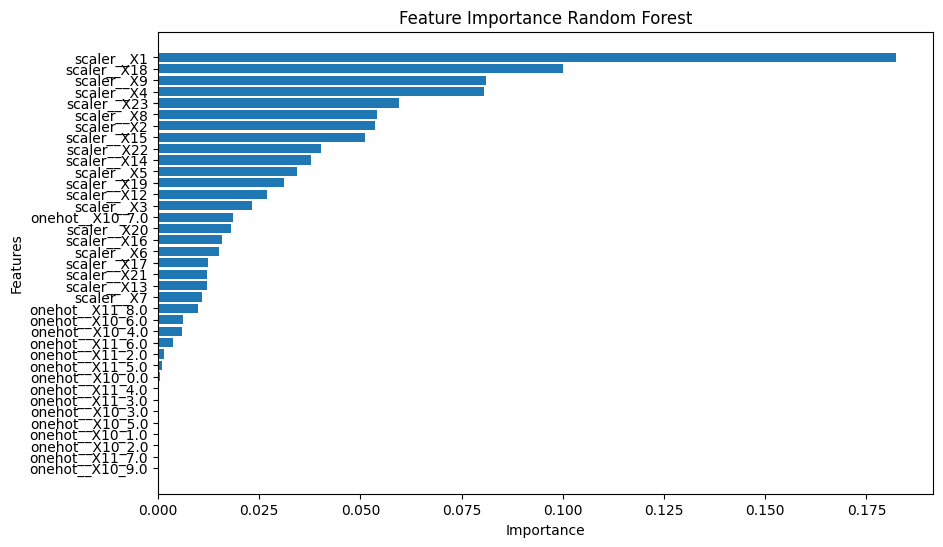

In [104]:
# Feature Importance Random Forest
pipeline = grid_search_rf.best_estimator_
rf_model = pipeline.named_steps['classifier']

features_after_preprocessing = pipeline.named_steps['pre'].get_feature_names_out()

feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features_after_preprocessing,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Wykres 
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance Random Forest')
plt.gca().invert_yaxis()
plt.show()

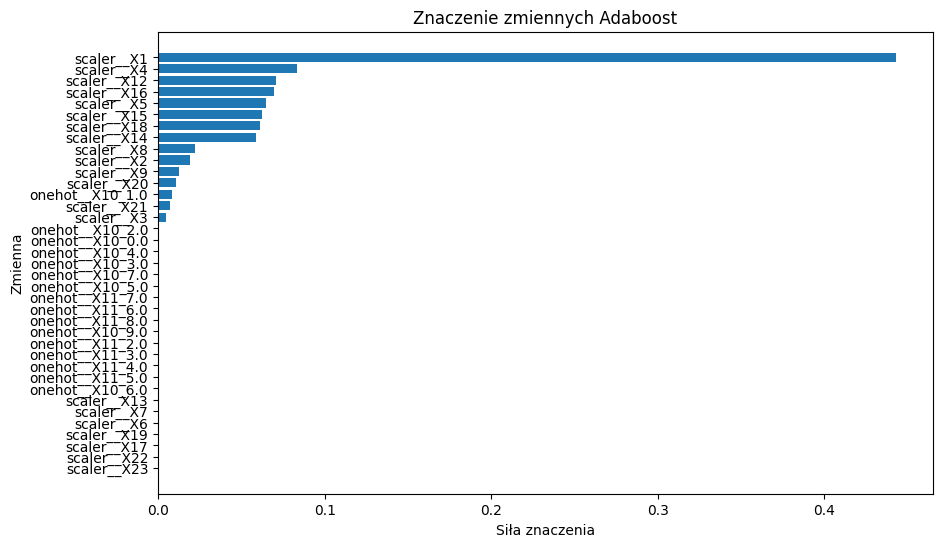

In [129]:
# Feature Importance Adaboost
pipeline = grid_search_adaboost.best_estimator_
rf_model = pipeline.named_steps['classifier']

features_after_preprocessing = pipeline.named_steps['pre'].get_feature_names_out()
feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features_after_preprocessing,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Wykres 
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Siła znaczenia')
plt.ylabel('Zmienna')
plt.title('Znaczenie zmiennych Adaboost')
plt.gca().invert_yaxis()
plt.show()

Być może moglibyśmy zwiększyć balanced accuracy usuwając cechy mało istotne. Być może również tak silne ograniczenie cech znaczący AdaBoost wpływa na jego najniższą miarę w aplikacji, mniej dostosowuje się do różnorodnych danych.

In [128]:
# print(grid_search_dt.best_params_)
# print(grid_search_lr.best_params_)
# print(grid_search_rf.best_params_)
# print(grid_search_knn.best_params_)
# print(grid_search_svm.best_params_)
# print(grid_search_extra.best_params_)
# print(grid_search_gradient.best_params_)
# print(grid_search_adaboost.best_params_)
# print(grid_search_bagging_dt.best_params_)
# print(grid_search_bagging_lr.best_params_)
# print(grid_search_bagging_knn.best_params_)
# print(grid_search_bagging_svm.best_params_)


{'classifier__criterion': 'entropy', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
{'classifier__C': 0.5, 'classifier__kernel': 'rbf'}
{'classifier__bootstrap': True, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
{'classifier__max_depth': 2, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
{'classifier__algorithm': 'SAMME', 'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__n_estimators': 200}
{'bagging__n_estimators': 

In [ ]:
#combined_df 